# Notebook 7 - AI Earthquake Risk Prediction

## Objectives

- Build an earthquake risk classification model
- Train a Random Forest classifier
- Evaluate model performance
- Predict seismic risk levels

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
earthquakes = pd.read_csv(
    "data/processed/earthquakes_processed.csv"
)

earthquakes.head()

,Time,Date,Year,Month,Day,Hour,Weekday,Latitude,Longitude,Depth_km,Magnitude,Location
0,2025-12-30 23:51:36.674000+00:00,2025-12-30,2025,12,30,23,Tuesday,39.4639,142.7562,35.000,4.8,"69 km E of Yamada, Japan"
1,2025-12-30 22:36:09.826000+00:00,2025-12-30,2025,12,30,22,Tuesday,3.0448,128.8654,10.000,4.5,"173 km NNE of Tobelo, Indonesia"
2,2025-12-30 22:25:43.819000+00:00,2025-12-30,2025,12,30,22,Tuesday,60.5503,-140.1190,5.000,3.3,"113 km N of Yakutat, Alaska"
3,2025-12-30 22:19:46.317000+00:00,2025-12-30,2025,12,30,22,Tuesday,39.5984,143.3045,27.735,4.8,"117 km E of Miyako, Japan"
4,2025-12-30 22:14:01.822000+00:00,2025-12-30,2025,12,30,22,Tuesday,62.7050,-149.2790,59.600,2.5,"51 km ENE of Chase, Alaska"


In [4]:
def classify_risk(mag):

    if mag < 4:
        return "Low"

    elif mag < 6:
        return "Moderate"

    else:
        return "High"

earthquakes["Risk"] = earthquakes["Magnitude"].apply(classify_risk)

earthquakes["Risk"].value_counts()

Risk
Moderate    12628
Low          7264
High          108
Name: count, dtype: int64

In [5]:
features = earthquakes[
    [
        "Latitude",
        "Longitude",
        "Depth_km",
        "Magnitude"
    ]
].dropna()

target = earthquakes.loc[
    features.index,
    "Risk"
]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

In [7]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [8]:
predictions = model.predict(X_test)

predictions[:10]

array(['Low', 'Moderate', 'Low', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Low', 'Moderate'], dtype=object)

In [9]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


In [10]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        21
         Low       1.00      1.00      1.00      1453
    Moderate       1.00      1.00      1.00      2526

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [11]:
cm = confusion_matrix(
    y_test,
    predictions
)

cm

array([[  21,    0,    0],
       [   0, 1453,    0],
       [   0,    0, 2526]])

In [12]:
importance = pd.DataFrame({

    "Feature": features.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Magnitude,0.652028
1,Longitude,0.217243
0,Latitude,0.113848
2,Depth_km,0.016881


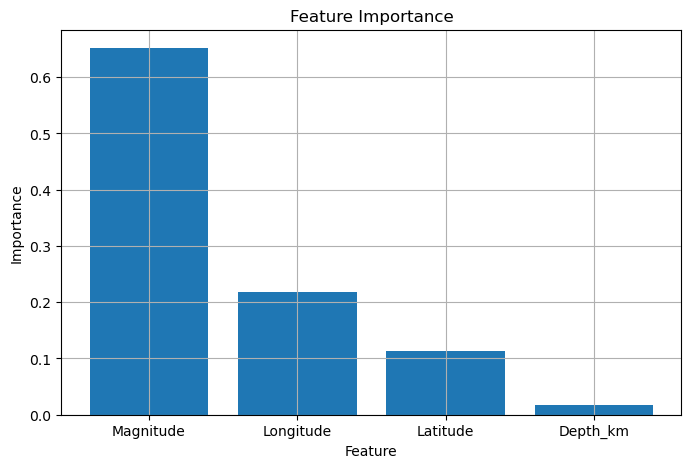

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Feature")

plt.ylabel("Importance")

plt.grid(True)

plt.show()

In [14]:
importance.to_csv(
    "outputs/reports/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [1]:
import pandas as pd

earthquakes = pd.read_csv("data/processed/earthquakes_processed.csv")

print(earthquakes.columns.tolist())

['Time', 'Date', 'Year', 'Month', 'Day', 'Hour', 'Weekday', 'Latitude', 'Longitude', 'Depth_km', 'Magnitude', 'Location']
